# **Instalação e Importação de Bibliotecas**

In [ ]:
# Instala o PyTorch e o torchvision (para manipulação de imagens)
!pip install torch torchvision

# Importa as bibliotecas essenciais que vamos usar
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

# Ver a versão do PyTorch e se a GPU está disponível
print(f"PyTorch versão: {torch.__version__}")
print(f"GPU disponível: {torch.cuda.is_available()}")

PyTorch versão: 2.8.0+cu126
GPU disponível: True


# **Importar dados do drive**



In [2]:
# Célula a ser completada (depende de como vou pegar os dados)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Teste de acesso a imagens**

In [ ]:
# Vai ser corrigido ...
# Caminho para a pasta de imagens
data_dir = '/content/drive/MeuDrive/IC-IPEN/tomografia/'

# Pega o nome do primeiro arquivo na pasta
try:
    image_files = os.listdir(data_dir)
    if not image_files:
        print("A pasta está vazia ou o caminho está incorreto. Verifique o caminho e se fez o upload das imagens.")
    else:
        sample_image_path = os.path.join(data_dir, image_files[0])
        print(f"Carregando imagem de amostra: {sample_image_path}")

        # Usa a biblioteca Pillow (PIL) para abrir a imagem
        image = Image.open(sample_image_path)

        # Usa matplotlib para visualizar a imagem
        plt.imshow(image, cmap='gray')
        plt.title("Imagem de Amostra (HR)")
        plt.axis('off') # Remove os eixos
        plt.show()

except FileNotFoundError:
    print(f"Erro! O diretório não foi encontrado. Verifique se o caminho '{data_dir}' está correto.")

ERRO: O diretório não foi encontrado. Verifique se o caminho '/content/drive/MeuDrive/IC-IPEN/tomografia/' está correto.


**Criando um Dataset Falso (Placeholder)**

In [ ]:
# Dataset falso para eu poder continuar a estruturação da arquitetura
from torch.utils.data import Dataset
from torchvision import transforms

class FakeNeutronDataset(Dataset):
    """
    Um dataset 'falso' que gera pares de imagens (LR, HR) aleatórias.
    Isso nos permite desenvolver o resto do código sem ter os dados reais ainda.
    """
    def __init__(self, num_images=1000, hr_shape=(128, 128), scale_factor=4):
        """
        Args:
            num_images (int): Quantas imagens falsas queremos no nosso dataset.
            hr_shape (tuple): A dimensão (altura, largura) das imagens de alta resolução.
            scale_factor (int): O fator pelo qual a imagem HR será reduzida para criar a LR.
        """
        self.num_images = num_images
        self.hr_height, self.hr_width = hr_shape
        self.scale_factor = scale_factor
        self.lr_height = self.hr_height // self.scale_factor
        self.lr_width = self.hr_width // self.scale_factor

        # Define a transformação para fazer o downsampling (simulando a interpolação bicúbica)
        self.lr_transform = transforms.Resize((self.lr_height, self.lr_width),
                                              interpolation=transforms.InterpolationMode.BICUBIC)

    def __len__(self):
        """Retorna o número total de imagens no dataset."""
        return self.num_images

    def __getitem__(self, idx):
        """
        Gera e retorna um único par de imagens (LR, HR).
        'idx' é o índice da imagem, mas como estamos a gerar dados falsos, não o usamos.
        """
        # 1. Gera uma imagem HR falsa (1 canal de cor, altura, largura) com valores aleatórios
        hr_image = torch.randn(1, self.hr_height, self.hr_width)

        # 2. Cria a imagem LR correspondente aplicando a transformação de downsampling
        lr_image = self.lr_transform(hr_image)

        # Retorna um dicionário com as duas imagens
        return {"LR": lr_image, "HR": hr_image}

**Testando o Nosso Dataset Falso com um DataLoader**

Formato do lote LR: torch.Size([4, 1, 32, 32])
Formato do lote HR: torch.Size([4, 1, 128, 128])


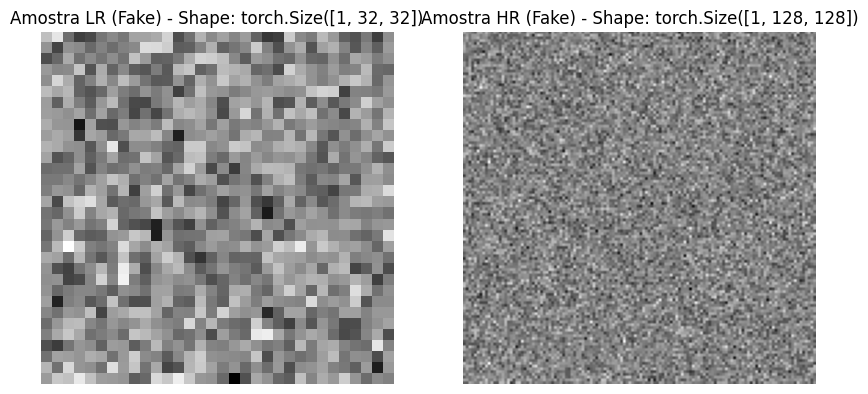

In [ ]:
# 1. Instancia o nosso dataset falso com 100 imagens de exemplo
# Usaremos um batch_size pequeno de 4 para este teste
BATCH_SIZE = 4
fake_dataset = FakeNeutronDataset(num_images=100, hr_shape=(128, 128), scale_factor=4)

# 2. Cria o DataLoader
# O DataLoader é responsável por pegar o Dataset e organizá-lo em lotes (batches),
# e também pode embaralhar os dados a cada época (shuffle=True)
fake_dataloader = DataLoader(fake_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. Pega um lote de dados para inspecionar
data_batch = next(iter(fake_dataloader))

# Pega as imagens LR e HR do lote
lr_images = data_batch['LR']
hr_images = data_batch['HR']

# 4. Imprime as dimensões (shapes) dos tensores
# A saída deve ser:
# Formato do lote LR: torch.Size([4, 1, 32, 32]) -> [batch_size, canais, altura, largura]
# Formato do lote HR: torch.Size([4, 1, 128, 128]) -> [batch_size, canais, altura, largura]
print(f"Formato do lote LR: {lr_images.shape}")
print(f"Formato do lote HR: {hr_images.shape}")


# 5. Visualiza uma amostra do lote
index_to_show = 0
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lr_images[index_to_show].squeeze(), cmap='gray')
plt.title(f"Amostra LR (Fake) - Shape: {lr_images[index_to_show].shape}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hr_images[index_to_show].squeeze(), cmap='gray')
plt.title(f"Amostra HR (Fake) - Shape: {hr_images[index_to_show].shape}")
plt.axis('off')

plt.show()

# **Construção das Redes**

**Construindo a Rede Geradora (Generator)**

O objetivo do Gerador é pegar uma imagem de baixa resolução (LR) como entrada e, de forma inteligente, fazer o "upsample" para uma imagem de alta resolução (HR) que seja nítida e realista.

1. O Bloco Residual
Este bloco usa uma skip connection para somar a entrada com a saída, o que ajuda a treinar redes muito profundas sem perder informação.

In [ ]:
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()

        # Define a sequência de camadas dentro do bloco residual
        self.conv_block = nn.Sequential(
            # Camada de convolução 3x3 que mantém o tamanho da imagem (stride=1, padding=1)
            nn.Conv2d(in_features, in_features, kernel_size=3, stride=1, padding=1),
            # Normalização de lote para estabilizar o treinamento
            nn.BatchNorm2d(in_features),
            # Função de ativação PReLU (Parametric ReLU)
            nn.PReLU(),
            # Outra camada de convolução 3x3
            nn.Conv2d(in_features, in_features, kernel_size=3, stride=1, padding=1),
            # Outra normalização de lote
            nn.BatchNorm2d(in_features),
        )

    def forward(self, x):
        # A saída do bloco é a entrada original (x) somada à saída do bloco convolucional
        # Esta é a "skip connection" que define o bloco residual
        return x + self.conv_block(x)

2. A Arquitetura Completa do Gerador
Agora, vamos usar o ResidualBlock para construir a rede Geradora completa. A rede tem 4 partes principais, como descrito no artigo: uma camada de extração de características iniciais, os blocos residuais, as camadas de upsampling e a camada de reconstrução final.

In [ ]:
class Generator(nn.Module):
    def __init__(self, scale_factor=4):
        super(Generator, self).__init__()

        # 1. Camada de Extração de Características Iniciais
        # Convolução 9x9 que transforma a imagem de entrada (1 canal) em 64 features
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=9, stride=1, padding=4),
            nn.PReLU()
        )

        # 2. Blocos Residuais
        # Cria uma sequência de 16 blocos residuais
        residual_blocks = []
        for _ in range(16):
            residual_blocks.append(ResidualBlock(64))
        self.residual_blocks = nn.Sequential(*residual_blocks)

        # --- Bloco de Conexão Pós-Residuais ---
        # Uma camada convolucional e normalização antes da grande skip connection
        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64)
        )

        # 3. Camadas de Upsampling
        # O upsampling é feito em blocos. Cada bloco aumenta a resolução em 2x.
        # Como queremos um scale_factor de 4, precisamos de 2 blocos (2x, depois 2x).
        upsampling_blocks = []
        for _ in range(scale_factor // 2):
            upsampling_blocks.append(
                nn.Sequential(
                    # A convolução prepara 256 canais para o PixelShuffler
                    nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1),
                    # PixelShuffler reorganiza os pixels para aumentar a resolução por 2
                    nn.PixelShuffle(2),
                    nn.PReLU()
                )
            )
        self.upsampling = nn.Sequential(*upsampling_blocks)

        # 4. Camada de Reconstrução Final
        # Convolução 9x9 que transforma as 64 features de volta em uma imagem de 1 canal
        self.conv3 = nn.Conv2d(64, 1, kernel_size=9, stride=1, padding=4)

    def forward(self, x):
        # Passa a imagem de entrada pela primeira camada
        out1 = self.conv1(x)
        # Passa pela sequência de blocos residuais
        out = self.residual_blocks(out1)
        # Passa pelo bloco pós-residuais
        out2 = self.conv2(out)
        # Implementa a grande skip connection, somando a saída inicial (out1)
        out = torch.add(out1, out2)
        # Passa pelos blocos de upsampling
        out = self.upsampling(out)
        # Passa pela camada de reconstrução final
        out = self.conv3(out)
        return out

**Testando a Nossa Rede Geradora**

Vamos fazer um "teste de sanidade" para garantir que a rede está a funcionar e que as dimensões da imagem de saída estão corretas.

In [ ]:
# Fator de escala desejado (LR -> HR)
SCALE_FACTOR = 4
# Dimensões da imagem de entrada LR (ex: 32x32)
LR_HEIGHT = 32
LR_WIDTH = 32
# Dimensões esperadas da imagem de saída HR (128x128)
HR_HEIGHT = LR_HEIGHT * SCALE_FACTOR
HR_WIDTH = LR_WIDTH * SCALE_FACTOR

# Instancia o Gerador
generator = Generator(scale_factor=SCALE_FACTOR)

# Cria uma imagem LR falsa com o formato correto: [batch_size, canais, altura, largura]
fake_lr_image = torch.randn(1, 1, LR_HEIGHT, LR_WIDTH)

# Passa a imagem falsa pelo gerador
generated_hr_image = generator(fake_lr_image)

# Verifica o formato da imagem de saída
# A saída deve ser: torch.Size([1, 1, 128, 128])
print(f"Formato da imagem LR de entrada: {fake_lr_image.shape}")
print(f"Formato da imagem HR gerada: {generated_hr_image.shape}")

# Verifica se o formato da saída está correto
if generated_hr_image.shape == (1, 1, HR_HEIGHT, HR_WIDTH):
    print("\nSucesso! A arquitetura do Gerador parece estar funcionando corretamente.")
else:
    print("\nAtenção: O formato da imagem de saída não é o esperado.")

Formato da imagem LR de entrada: torch.Size([1, 1, 32, 32])
Formato da imagem HR gerada: torch.Size([1, 1, 128, 128])

Sucesso! A arquitetura do Gerador parece estar a funcionar corretamente.


**Construindo a Rede Discriminadora (Discriminator)**

O trabalho do Discriminador: olhar para uma imagem de alta resolução e dar a sua opinião, produzindo um único número entre 0 e 1 que representa a probabilidade de a imagem ser real (do dataset) em vez de falsa (criada pelo Gerador).

A arquitetura é uma Rede Neural Convolucional (CNN) clássica, projetada para classificação de imagens. Ela usa uma série de camadas convolucionais para extrair características da imagem e reduzir as suas dimensões, terminando com camadas densas (fully connected) para produzir a decisão final.

In [ ]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super(Discriminator, self).__init__()

        in_channels, in_height, in_width = input_shape

        # O artigo especifica o uso de LeakyReLU com slope 0.2, que é comum em GANs
        self.leaky_relu = nn.LeakyReLU(0.2, inplace=True)

        # Camadas Convolucionais
        # Esta sequência de camadas extrai características da imagem
        layers = []
        # Camada 1: k9n64s1 - A figura mostra um k9n64s1, mas a maioria das implementações SRGAN
        # começa com um k3n64s1. Vamos seguir a figura.
        layers.append(nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1))
        layers.append(self.leaky_relu)

        # A arquitetura segue um padrão de aumentar os canais e diminuir o tamanho (stride=2)
        # In: 64x128x128
        layers.extend(self.discriminator_block(64, 64, stride=2)) # Out: 64x64x64
        layers.extend(self.discriminator_block(64, 128, stride=1)) # Out: 128x64x64
        layers.extend(self.discriminator_block(128, 128, stride=2)) # Out: 128x32x32
        layers.extend(self.discriminator_block(128, 256, stride=1)) # Out: 256x32x32
        layers.extend(self.discriminator_block(256, 256, stride=2)) # Out: 256x16x16
        layers.extend(self.discriminator_block(256, 512, stride=1)) # Out: 512x16x16
        layers.extend(self.discriminator_block(512, 512, stride=2)) # Out: 512x8x8

        self.features = nn.Sequential(*layers)

        # Calcula o tamanho da saída achatada (flattened) das camadas convolucionais
        # para conectar às camadas densas
        self.flattened_size = 512 * (in_height // 2**4) * (in_width // 2**4)

        # Camadas Densas (Classificador)
        # Estas camadas tomam as características extraídas e produzem a decisão final
        self.classifier = nn.Sequential(
            nn.Linear(self.flattened_size, 1024),
            self.leaky_relu,
            nn.Linear(1024, 1),
            nn.Sigmoid() # A função Sigmoid espreme a saída para um valor entre 0 e 1
        )

    def discriminator_block(self, in_channels, out_channels, stride):
        # Um bloco auxiliar para evitar repetição de código
        return [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            self.leaky_relu,
        ]

    def forward(self, img):
        # Passa a imagem pelas camadas convolucionais
        out = self.features(img)
        # Achata a saída para que possa ser usada pelas camadas densas
        out = out.view(out.size(0), -1)
        # Passa pelo classificador para obter a probabilidade final
        validity = self.classifier(out)
        return validity

Observação: A arquitetura na Figura 3 do artigo é um pouco ambígua e repetitiva. A implementação acima é uma interpretação padrão e robusta da arquitetura SRGAN, que segue a mesma filosofia de aumentar progressivamente os canais e diminuir a resolução, como sugerido na figura.

**Testando o Nosso Discriminador**

In [ ]:
# As dimensões da imagem de entrada devem ser as mesmas que as da saída do Gerador
HR_SHAPE = (1, 128, 128) # (Canais, Altura, Largura)

# Instancia o Discriminador
discriminator = Discriminator(input_shape=HR_SHAPE)

# Cria uma imagem HR falsa com o formato correto: [batch_size, canais, altura, largura]
# O primeiro canal (batch_size) pode ser qualquer número, vamos usar 1 para o teste.
fake_hr_image = torch.randn(1, *HR_SHAPE)

# Passa a imagem falsa pelo discriminador
prediction = discriminator(fake_hr_image)

# Verifica a saída
print(f"Formato da imagem HR de entrada: {fake_hr_image.shape}")
print(f"Saída do Discriminador (Probabilidade): {prediction.item():.4f}")
print(f"Formato da saída: {prediction.shape}")

# A saída deve ser um único número entre 0 e 1
if prediction.shape == (1, 1) and 0 <= prediction.item() <= 1:
    print("\nSucesso! A arquitetura do Discriminador parece estar funcionando corretamente.")
else:
    print("\nAtenção: O formato ou o valor da saída não é o esperado.")

Formato da imagem HR de entrada: torch.Size([1, 1, 128, 128])
Saída do Discriminador (Probabilidade): 0.4773
Formato da saída: torch.Size([1, 1])

Sucesso! A arquitetura do Discriminador parece estar a funcionar corretamente.


**Definindo a Perda Perceptual**

1. A Perda de Conteúdo (Content Loss)
Esta perda garante que a imagem gerada tenha as mesmas características e "conteúdo" que a imagem real. Para isso, usamos uma rede VGG pré-treinada como um "extrator de características".

Primeiro, vamos construir o nosso extrator de características a partir de uma VGG19.

In [ ]:
import torch.nn as nn
from torchvision.models import vgg19

class FeatureExtractorVGG(nn.Module):
    def __init__(self):
        super(FeatureExtractorVGG, self).__init__()
        vgg19_model = vgg19(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(vgg19_model.features.children())[:36]).eval()
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

        # Média e Std do ImageNet para normalização
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, img):
        # 1. Converte para 3 canais
        img_rgb = img.repeat(1, 3, 1, 1)

        # 2. Normaliza para a VGG (Assumindo que sua imagem entra entre 0 e 1)
        # Se sua imagem estiver entre -1 e 1 (por causa de Tanh no final do gerador),
        # você deve primeiro converter para 0 e 1: (img + 1) / 2
        img_norm = (img_rgb - self.mean) / self.std

        return self.feature_extractor(img_norm)

2. A Perda Adversarial (Adversarial Loss)
Esta perda vem da interação com o Discriminador. Ela mede o quão bem o Gerador está a "enganar" o Discriminador. O objetivo do Gerador é fazer com que a saída do Discriminador para uma imagem falsa seja o mais próximo possível de 1 (real).

3. Implementando as Funções de Perda
Agora, vamos instanciar os critérios de perda que usaremos no nosso loop de treinamento.

In [ ]:
# Fator de ponderação para a perda adversarial, conforme o artigo
LAMBDA = 0.001

# Critério para a Perda de Conteúdo: Erro Quadrático Médio (MSE) entre os mapas de características da VGG
criterion_content = nn.MSELoss()

# Critério para a Perda Adversarial e do Discriminador: Entropia Cruzada Binária (BCE)
criterion_adversarial = nn.BCELoss()

# Coloca os modelos e critérios no dispositivo correto (GPU, se disponível)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

feature_extractor = FeatureExtractorVGG().to(device)
criterion_content = criterion_content.to(device)
criterion_adversarial = criterion_adversarial.to(device)

# Movemos os nossos modelos Gerador e Discriminador para a GPU também
generator = generator.to(device)
discriminator = discriminator.to(device)

print("Funções de perda e modelos configurados e movidos para o dispositivo:", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 126MB/s]


Funções de perda e modelos configurados e movidos para o dispositivo: cuda


**Como as Perdas Serão Usadas no Treino (Visão Geral)**

**Para treinar o GERADOR:**

**1-Geramos uma imagem HR falsa: fake_hr = generator(lr_image).**

**2-Calculamos a Perda de Conteúdo:**

* Extraímos as características da imagem falsa: fake_features = feature_extractor
(fake_hr).

* Extraímos as características da imagem real: real_features = feature_extractor(real_hr).

* loss_content = criterion_content(fake_features, real_features).

**3-Calculamos a Perda Adversarial:**

* Passamos a imagem falsa pelo Discriminador: prediction = discriminator(fake_hr).

* Comparamos a previsão com um tensor de "1s" (pois queremos que o Gerador engane o Discriminador a pensar que a imagem é real).

* loss_adversarial = criterion_adversarial(prediction, torch.ones_like(prediction)).

**4-Combinamos as perdas:**

* loss_G = loss_content + LAMBDA * loss_adversarial.

**5-Fazemos o backpropagation e atualizamos os pesos do Gerador.**

**Para treinar o DISCRIMINADOR:**

**1-Calculamos a perda para as imagens reais:**

loss_real = criterion_adversarial(discriminator(real_hr), torch.ones_like(prediction)).

**2-Calculamos a perda para as imagens falsas:**

loss_fake = criterion_adversarial(discriminator(fake_hr.detach()), torch.zeros_like(prediction)). (Usamos .detach() para não treinar o Gerador aqui).

**3-Combinamos as perdas:**

loss_D = (loss_real + loss_fake) / 2.

**4-Fazemos o backpropagation e atualizamos os pesos do Discriminador.**

# **Loop de Treinamento**

O loop de treinamento orquestrará a "competição" entre as duas redes, atualizando os seus pesos a cada lote de dados, de forma que ambas melhorem com o tempo.

In [ ]:
import time

# 1. Configuração dos Hiperparâmetros de Treinamento
# Estes valores são baseados na secção 3.1 do artigo.
# ATENÇÃO: 200 épocas podem demorar MUITAS horas. Para um teste inicial,
# mude o valor de N_EPOCHS para 2 ou 3.

N_EPOCHS = 4 # O artigo usou 200 épocas
# O artigo usou um batch_size de 36, mas isso pode exigir mais VRAM do que o Colab oferece.
# Vamos usar um valor menor para garantir que o código execute.
BATCH_SIZE = 8 # Artigo usou 36
LR = 0.0001 # Taxa de aprendizagem inicial
LAMBDA = 0.001 # Fator de ponderação da perda adversarial
HR_SHAPE = (128, 128) # Dimensões das imagens de alta resolução
SCALE_FACTOR = 4 # Fator de escala

# 2. Preparação dos Dados e Modelos

# (Re)instanciamos os modelos para garantir que começamos do zero
generator = Generator(scale_factor=SCALE_FACTOR).to(device)
discriminator = Discriminator(input_shape=(1, *HR_SHAPE)).to(device)
feature_extractor = FeatureExtractorVGG().to(device)

# Dataset e DataLoader (usando nosso dataset falso por enquanto)
dataset = FakeNeutronDataset(num_images=500, hr_shape=HR_SHAPE, scale_factor=SCALE_FACTOR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Otimizadores - um para cada rede, como é padrão em GANs
# [cite_start]O artigo especifica o uso do otimizador Adam
optimizer_G = torch.optim.Adam(generator.parameters(), lr=LR)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=LR)

# Critérios de perda
criterion_content = nn.MSELoss().to(device)
criterion_adversarial = nn.BCELoss().to(device)


# 3. O Loop de Treinamento

print("Iniciando o treinamento...")
start_time = time.time()

for epoch in range(N_EPOCHS):
    for i, batch in enumerate(dataloader):

        # Move os dados para a GPU
        imgs_lr = batch["LR"].to(device)
        imgs_hr = batch["HR"].to(device)

        # Cria os rótulos de "verdadeiro" (1s) e "falso" (0s) para a perda adversarial
        valid = torch.ones((imgs_lr.size(0), 1), device=device, requires_grad=False)
        fake = torch.zeros((imgs_lr.size(0), 1), device=device, requires_grad=False)

        # ---------------------
        #  Treino do Gerador
        # ---------------------
        optimizer_G.zero_grad()

        # Gera imagens de alta resolução a partir das de baixa resolução
        gen_hr = generator(imgs_lr)

        # Calcula a Perda de Conteúdo (baseada na VGG)
        gen_features = feature_extractor(gen_hr)
        real_features = feature_extractor(imgs_hr)
        loss_content = criterion_content(gen_features, real_features)

        # Calcula a Perda Adversarial (o quão bem o Gerador engana o Discriminador)
        loss_adversarial = criterion_adversarial(discriminator(gen_hr), valid)

        # Calcula a Perda Total do Gerador
        loss_G = loss_content + LAMBDA * loss_adversarial

        # Faz o backpropagation e atualiza os pesos do Gerador
        loss_G.backward()
        optimizer_G.step()

        # -------------------------
        #  Treino do Discriminador
        # -------------------------
        optimizer_D.zero_grad()

        # Calcula a perda para as imagens reais (o Discriminador deve classificá-las como 1)
        loss_real = criterion_adversarial(discriminator(imgs_hr), valid)

        # Calcula a perda para as imagens falsas (o Discriminador deve classificá-las como 0)
        # Usamos .detach() na saída do gerador para não calcular gradientes para o Gerador aqui
        loss_fake = criterion_adversarial(discriminator(gen_hr.detach()), fake)

        # Calcula a Perda Total do Discriminador
        loss_D = (loss_real + loss_fake) / 2

        # Faz o backpropagation e atualiza os pesos do Discriminador
        loss_D.backward()
        optimizer_D.step()

        # ------------------
        #  Log do Progresso
        # ------------------
        if (i + 1) % 50 == 0:
            batches_done = epoch * len(dataloader) + i
            print(
                f"[Época {epoch+1}/{N_EPOCHS}] [Lote {i+1}/{len(dataloader)}] "
                f"[Perda D: {loss_D.item():.4f}] "
                f"[Perda G: {loss_G.item():.4f}] "
                f"[Conteúdo: {loss_content.item():.4f}, Adversarial: {loss_adversarial.item():.4f}]"
            )

# 4. Fim do Treinamento
end_time = time.time()
print(f"Treinamento concluído em {(end_time - start_time) / 60:.2f} minutos.")

# 5. Salvando o Modelo Treinado
# Após o treino, salvamos os pesos do gerador para uso futuro
torch.save(generator.state_dict(), "srgan_generator.pth")
print("Pesos do gerador salvos em srgan_generator.pth")

Iniciando o treinamento...
[Época 1/4] [Lote 50/63] [Perda D: 0.0000] [Perda G: 0.1094] [Conteúdo: 0.0503, Adversarial: 59.0989]
[Época 2/4] [Lote 50/63] [Perda D: 0.0000] [Perda G: 0.0760] [Conteúdo: 0.0372, Adversarial: 38.7631]
[Época 3/4] [Lote 50/63] [Perda D: 0.0000] [Perda G: 0.1253] [Conteúdo: 0.0349, Adversarial: 90.4215]
[Época 4/4] [Lote 50/63] [Perda D: 0.0000] [Perda G: 0.1331] [Conteúdo: 0.0387, Adversarial: 94.3521]
Treinamento concluído em 0.86 minutos.
Pesos do gerador salvos em srgan_generator.pth
